# EDA — Rheumatic & Autoimmune Disease Dataset

**Nguồn**: Harvard Dataverse, DOI `10.7910/DVN/VM4OR3` — người dùng tự tải tay (bị AWS WAF chặn khi thử tự động).

**File**: `Data/tabular/rheumatic_dataverse/Rheumatic and Autoimmune Disease Dataset.xlsx` — 12.085 dòng × 15 cột: Age, Gender, **ESR, CRP**, RF, Anti-CCP, HLA-B27, ANA, Anti-Ro, Anti-La, Anti-dsDNA, Anti-Sm, C3, C4, **Disease** (nhãn 7 lớp).

Đây là dataset chất lượng tốt nhất trong kho — bù được CRP/ESR (trước đó hoàn toàn không có nguồn nào).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 5)
DATA = Path(r'D:\AI_08_V1\Data')

df = pd.read_excel(DATA / 'tabular' / 'rheumatic_dataverse' / 'Rheumatic and Autoimmune Disease Dataset.xlsx')
print('Shape:', df.shape)
print('Dòng trùng lặp:', df.duplicated().sum())
print('\nMissing values theo cột:')
print(df.isna().sum())

Shape: (12085, 15)
Dòng trùng lặp: 0

Missing values theo cột:
Age              0
Gender           0
ESR           1088
CRP           2417
RF            1329
Anti-CCP      3263
HLA-B27       1934
ANA           3746
Anti-Ro       2900
Anti-La       3021
Anti-dsDNA    4713
Anti-Sm       5197
C3            1692
C4            2054
Disease          0
dtype: int64


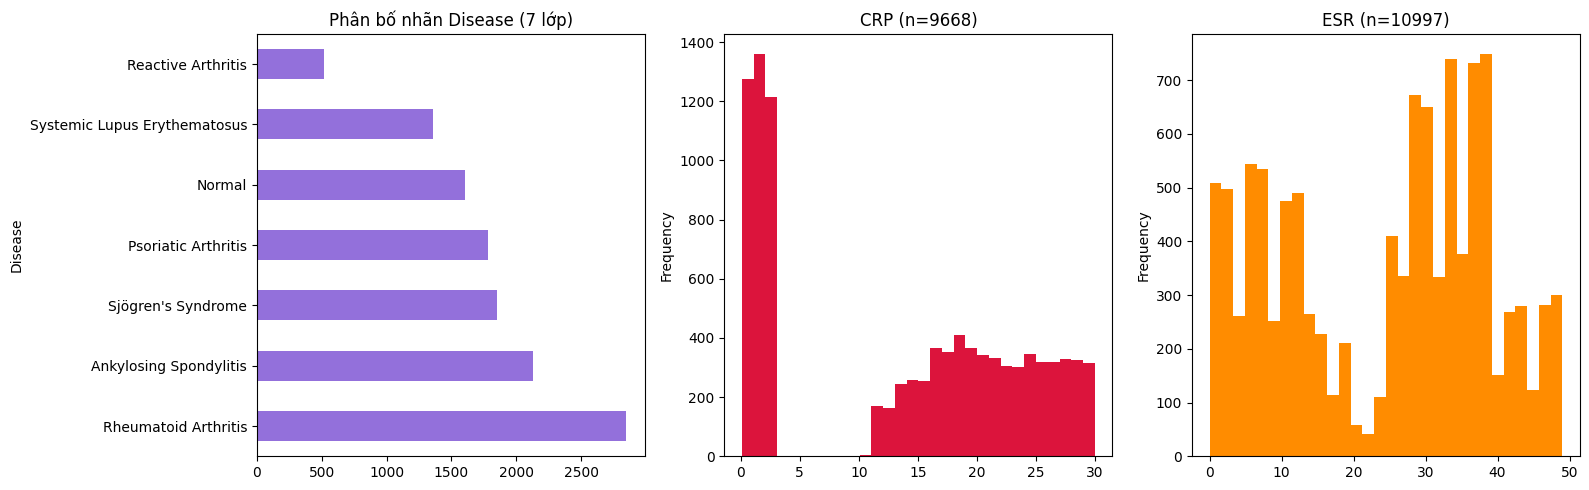

           CRP       ESR       Age
count  9668.00  10997.00  12085.00
mean     13.33     24.21     49.91
std      10.39     14.37     17.65
min       0.10      0.00     20.00
25%       1.90     10.00     35.00
50%      15.60     28.00     50.00
75%      22.60     36.00     65.00
max      30.00     49.00     80.00


In [2]:
# Phân bố nhãn Disease + thống kê CRP/ESR
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
df['Disease'].value_counts().plot.barh(ax=axes[0], color='mediumpurple')
axes[0].set_title('Phân bố nhãn Disease (7 lớp)')
df['CRP'].dropna().plot.hist(ax=axes[1], bins=30, color='crimson')
axes[1].set_title(f"CRP (n={df['CRP'].notna().sum()})")
df['ESR'].dropna().plot.hist(ax=axes[2], bins=30, color='darkorange')
axes[2].set_title(f"ESR (n={df['ESR'].notna().sum()})")
plt.tight_layout()
plt.show()

print(df[['CRP', 'ESR', 'Age']].describe().round(2))

In [3]:
# CRP/ESR trung bình theo từng nhóm bệnh — kiểm tra tín hiệu phân biệt
df.groupby('Disease')[['CRP', 'ESR']].mean().round(2).sort_values('CRP', ascending=False)

,CRP,ESR
Disease,,
Psoriatic Arthritis,23.00,40.17
Ankylosing Spondylitis,21.58,32.35
Rheumatoid Arthritis,20.62,35.09
Reactive Arthritis,15.45,24.92
Normal,1.57,8.13
Systemic Lupus Erythematosus,1.55,8.33
Sjögren's Syndrome,1.51,8.19


## Nhận xét

- **Chất lượng tốt nhất kho**: 0 dòng trùng lặp, cỡ mẫu lớn (12.085 dòng).
- Missing value ở các cột huyết thanh học (ESR ~9%, CRP ~20%, các marker khác 15–43%) — hợp lý vì không phải bệnh nhân nào cũng làm đủ panel.
- 7 lớp Disease, lớp nhỏ nhất (Reactive Arthritis) vẫn có 516 mẫu — mức mất cân bằng chấp nhận được.
- **Giới hạn quan trọng**: đây là bệnh tự miễn/thấp khớp, không thuộc 9 nhóm bệnh huyết học mục tiêu — chỉ dùng để bù CRP/ESR làm dữ liệu tham chiếu, không dùng làm nhãn chính.